In [29]:
!pip install apriori_python
!pip install efficient-apriori
!pip install fpgrowth_py
!pip install pyarmviz

In [ ]:
# @title
# helpers

from apriori_python import apriori
import pandas as pd

df = pd.read_csv('/content/BreadBasket_DMS_tmp.csv')
transactions = df.groupby('Transaction')['Item'].apply(list).tolist()
freqItemSet, minConf60 = apriori(transactions, minSup=0, minConf=0.6)

print(minConf60)

# transactions = [['Тетрадь', 'Ручка', 'Краски'],
#                 ['Тетрадь', 'Ручка', 'Кисть'],
#                 ['Краски', 'Ручка', 'Ластик']]
# def data_generator(filename):
#   def data_gen():
#     with open(filename) as file:
#       for line in file:
#         yield tuple(k.strip() for k in line.split(','))

# rules_df = pd.DataFrame(
#     [(list(rule.lhs), list(rule.rhs), rule.support, rule.confidence, rule.lift, rule.conviction)
#      for rule in rules60],
#     columns=['lhs', 'rhs', 'support', 'confidence', 'lift', 'conviction']
# )
# print(rules_df.head())

# rules_rhs = filter(lambda rule: len(rule.lhs) == 1 and len(rule.rhs) == 1, rules)

In [34]:
# @title
# Тестовые данные
from efficient_apriori import apriori
# from apriori_python import apriori
from fpgrowth_py import fpgrowth
import pandas as pd

df = pd.read_csv('/content/sports_store.csv')

transactions = df.groupby('Transaction')['Item'].apply(list).tolist()

freqItemSetApriori, rulesApriori = apriori(transactions, min_support=0.5, min_confidence=0.5)
# freqItemSet, rulesApriori = apriori(transactions, minSup=0.5, minConf=0.5)

print('Алгоритм Apriori')
for rule in sorted(rulesApriori, key=lambda rule: rule.confidence):
    print(rule)
# for rule in rulesApriori:
#   print(rule)

print('Алгоритм FPGrowth')
freqItemSetFGP, rulesFGP = fpgrowth(transactions, minSupRatio=0.5, minConf=0.5)
for rule in rulesFGP:
  print(rule)

Алгоритм Apriori
{T-shirt} -> {Ball} (conf: 0.696, supp: 0.533, lift: 1.159, conv: 1.314)
{Ball} -> {T-shirt} (conf: 0.889, supp: 0.533, lift: 1.159, conv: 2.100)
Алгоритм FPGrowth
[{'Ball'}, {'T-shirt'}, 0.8888888888888888]
[{'T-shirt'}, {'Ball'}, 0.6956521739130435]


In [18]:
from efficient_apriori import apriori
import pandas as pd
from PyARMViz import PyARMViz

df = pd.read_csv('/content/BreadBasket_DMS.csv')
transactions = df.groupby('Transaction')['Item'].apply(list).tolist()

freqItemSet, rules60 = apriori(transactions, min_support=0.001, min_confidence=0)

# for rule in sorted(rules60, key=lambda rule: rule.confidence):
#   print(rule)

print(rules60)
PyARMViz.metadata_scatter_plot(rules60)


[{Bread} -> {Alfajores}, {Alfajores} -> {Bread}, {Brownie} -> {Alfajores}, {Alfajores} -> {Brownie}, {Cake} -> {Alfajores}, {Alfajores} -> {Cake}, {Coffee} -> {Alfajores}, {Alfajores} -> {Coffee}, {Cookies} -> {Alfajores}, {Alfajores} -> {Cookies}, {Hot chocolate} -> {Alfajores}, {Alfajores} -> {Hot chocolate}, {Juice} -> {Alfajores}, {Alfajores} -> {Juice}, {Medialuna} -> {Alfajores}, {Alfajores} -> {Medialuna}, {Mineral water} -> {Alfajores}, {Alfajores} -> {Mineral water}, {Muffin} -> {Alfajores}, {Alfajores} -> {Muffin}, {NONE} -> {Alfajores}, {Alfajores} -> {NONE}, {Pastry} -> {Alfajores}, {Alfajores} -> {Pastry}, {Sandwich} -> {Alfajores}, {Alfajores} -> {Sandwich}, {Scandinavian} -> {Alfajores}, {Alfajores} -> {Scandinavian}, {Scone} -> {Alfajores}, {Alfajores} -> {Scone}, {Spanish Brunch} -> {Alfajores}, {Alfajores} -> {Spanish Brunch}, {Tea} -> {Alfajores}, {Alfajores} -> {Tea}, {Truffles} -> {Alfajores}, {Alfajores} -> {Truffles}, {Coffee} -> {Art Tray}, {Art Tray} -> {Coffee

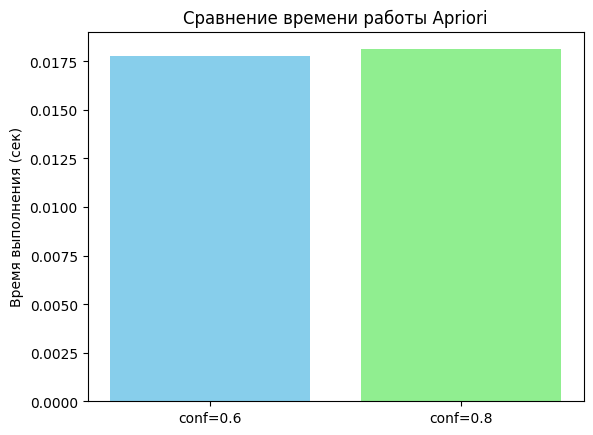

In [ ]:
# @title
import time
import pandas as pd
import matplotlib.pyplot as plt
from efficient_apriori import apriori

df = pd.read_csv('/content/BreadBasket_DMS_tmp.csv')
transactions = df.groupby('Transaction')['Item'].apply(list).tolist()

cases = {
    "conf=0.6": {"min_support": 0.001, "min_confidence": 0.6},
    "conf=0.8": {"min_support": 0.001, "min_confidence": 0.8},
}

times = {}

for label, params in cases.items():
    start = time.time()
    freqItemSet, rules = apriori(
        transactions,
        min_support=params["min_support"],
        min_confidence=params["min_confidence"]
    )
    end = time.time()
    times[label] = end - start

df_times = pd.DataFrame(list(times.items()), columns=["case", "time_sec"])

plt.bar(df_times["case"], df_times["time_sec"], color=["skyblue", "lightgreen"])
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение времени работы Apriori")
plt.show()


In [ ]:
from fpgrowth_py import fpgrowth
df = pd.read_csv('/content/BreadBasket_DMS_tmp.csv')
transactions = df.groupby('Transaction')['Item'].apply(list).tolist()

freqItemSet, rules60 = fpgrowth(transactions, minSupRatio=0, minConf=0.6)
print(rules)

            case     time_sec
0    Apriori 0.6     0.046331
1    Apriori 0.8     0.045299
2  FP-Growth 0.6  2369.874499
3  FP-Growth 0.8  2347.710495


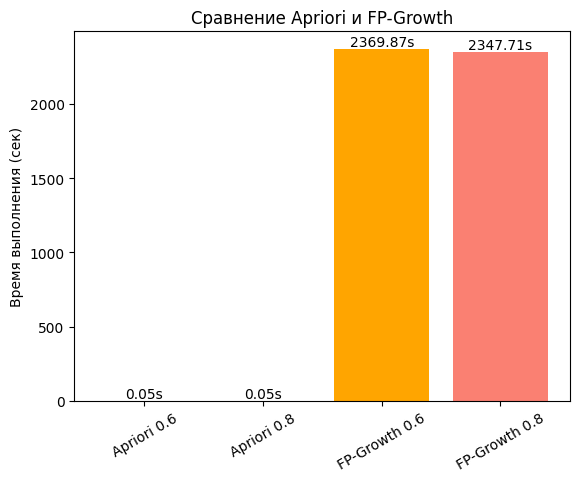

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from efficient_apriori import apriori
from fpgrowth_py import fpgrowth

df = pd.read_csv('/content/BreadBasket_DMS.csv')
transactions = df.groupby('Transaction')['Item'].apply(list).tolist()

cases = {
    "Apriori 0.6": ("apriori", {"min_support": 0.001, "min_confidence": 0.6}),
    "Apriori 0.8": ("apriori", {"min_support": 0.001, "min_confidence": 0.8}),
    "FP-Growth 0.6": ("fpgrowth", {"minSupRatio": 0, "minConf": 0.6}),
    "FP-Growth 0.8": ("fpgrowth", {"minSupRatio": 0, "minConf": 0.8}),
}

times = {}

for label, (algo, params) in cases.items():
    start = time.time()
    if algo == "apriori":
        freqItemSet, rules = apriori(
            transactions,
            min_support=params["min_support"],
            min_confidence=params["min_confidence"]
        )
    else:
        freqItemSet, rules = fpgrowth(
            transactions,
            minSupRatio=params["minSupRatio"],
            minConf=params["minConf"]
        )
    end = time.time()
    times[label] = end - start

df_times = pd.DataFrame(list(times.items()), columns=["case", "time_sec"])
print(df_times)

plt.bar(df_times["case"], df_times["time_sec"], color=["skyblue", "lightgreen", "orange", "salmon"])
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение Apriori и FP-Growth")
plt.xticks(rotation=30)

for i, v in enumerate(df_times["time_sec"]):
    plt.text(i, v, f"{v:.2f}s", ha="center", va="bottom")

plt.show()
